In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import shutil
import os

cache_paths = [
    "/tmp/train_cache",
    "/tmp/val_cache",
    "/tmp/test_cache"
]
# Clear any existing lockfiles for the cache paths
for cache_path in cache_paths:
    lockfile_path = f"{cache_path}_0.lockfile"
    if os.path.exists(lockfile_path):
        os.remove(lockfile_path)


#Imported all the Required Tools for Building a Model along with Calculating and Evaluating the Model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

import time
from tensorflow.keras.optimizers import SGD, Adam

In [ ]:
def make_callbacks(checkpoint_path):
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1)
    ]

#Shared evaluation helper
def evaluate_model(model, dataset, class_names, title="Model"):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        predicted_labels = np.argmax(preds, axis=1)
        y_pred.extend(predicted_labels)
        y_true.extend(labels.numpy())

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    # Classification report
    print(f'\n{title} — Classification Report')
    print(classification_report(y_true, y_pred,
                                labels=list(range(len(class_names))),
                                target_names=class_names))
    return y_true, y_pred

def make_callbacks(checkpoint_path):
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1)
    ]

def train_and_time(model, train_ds, val_ds, epochs, callbacks, initial_epoch=0):
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, initial_epoch=initial_epoch, callbacks=callbacks)
    elapsed = time.time() - start
    mins, secs = divmod(int(elapsed), 60)
    print(f'\n⏱  Total training time: {mins}m {secs}s ({elapsed:.1f}s)')
    return history, elapsed

#Accuracy + Loss plot helper
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} — Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} — Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend()
    plt.tight_layout(); plt.show()

#Defined a Fixed Image size and Batch Size to Work on

In [ ]:
img_size = (224, 224)
batch_size = 32

#Imported all the Data needed to Work

In [ ]:
train_dir = "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/train"
valid_dir = "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/valid"
test_dir = "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/test"

#Loading all the Images from the folder to work on Neural Network

In [ ]:
Train_Dataset = keras.utils.image_dataset_from_directory(train_dir, image_size = img_size, batch_size = batch_size, )
Validation_Dataset = keras.utils.image_dataset_from_directory(valid_dir, image_size = img_size, batch_size = batch_size)
Test_Dataset = keras.utils.image_dataset_from_directory(test_dir, image_size = img_size, batch_size = batch_size)

Found 9709 files belonging to 5 classes.
Found 200 files belonging to 5 classes.
Found 100 files belonging to 5 classes.


## Dataset Description

This project focuses on **fruit image classification**. The dataset is organized into `train`, `valid`, and `test` splits to ensure robust model evaluation, preventing data leakage and providing an unbiased assessment of the model's generalization capabilities.

### Preprocessing:

*   **Resizing**: All images are resized to `224x224` pixels to standardize input dimensions for the neural networks.
*   **Rescaling**: Pixel values are rescaled from the original `[0, 255]` range to `[0, 1]` by dividing by 255. This normalization helps the model converge faster and perform better.

### Augmentation:

To improve the model's ability to generalize and reduce overfitting, the following data augmentation techniques are applied to the training dataset:

*   **RandomFlip**: Images are randomly flipped horizontally and vertically.
*   **RandomRotation**: Images are randomly rotated by up to 20% of a full circle.
*   **RandomZoom**: Images are randomly zoomed in or out by up to 20%.

These augmentations create variations of the training images, making the model more robust to different orientations, sizes, and perspectives of the fruit images.

In [ ]:
Class_Names = Train_Dataset.class_names
Num_Classes = len(Class_Names)
print("Classes:", Class_Names)
print("Number of classes:", Num_Classes)

Classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Number of classes: 5


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = keras.layers.Rescaling(1./255)

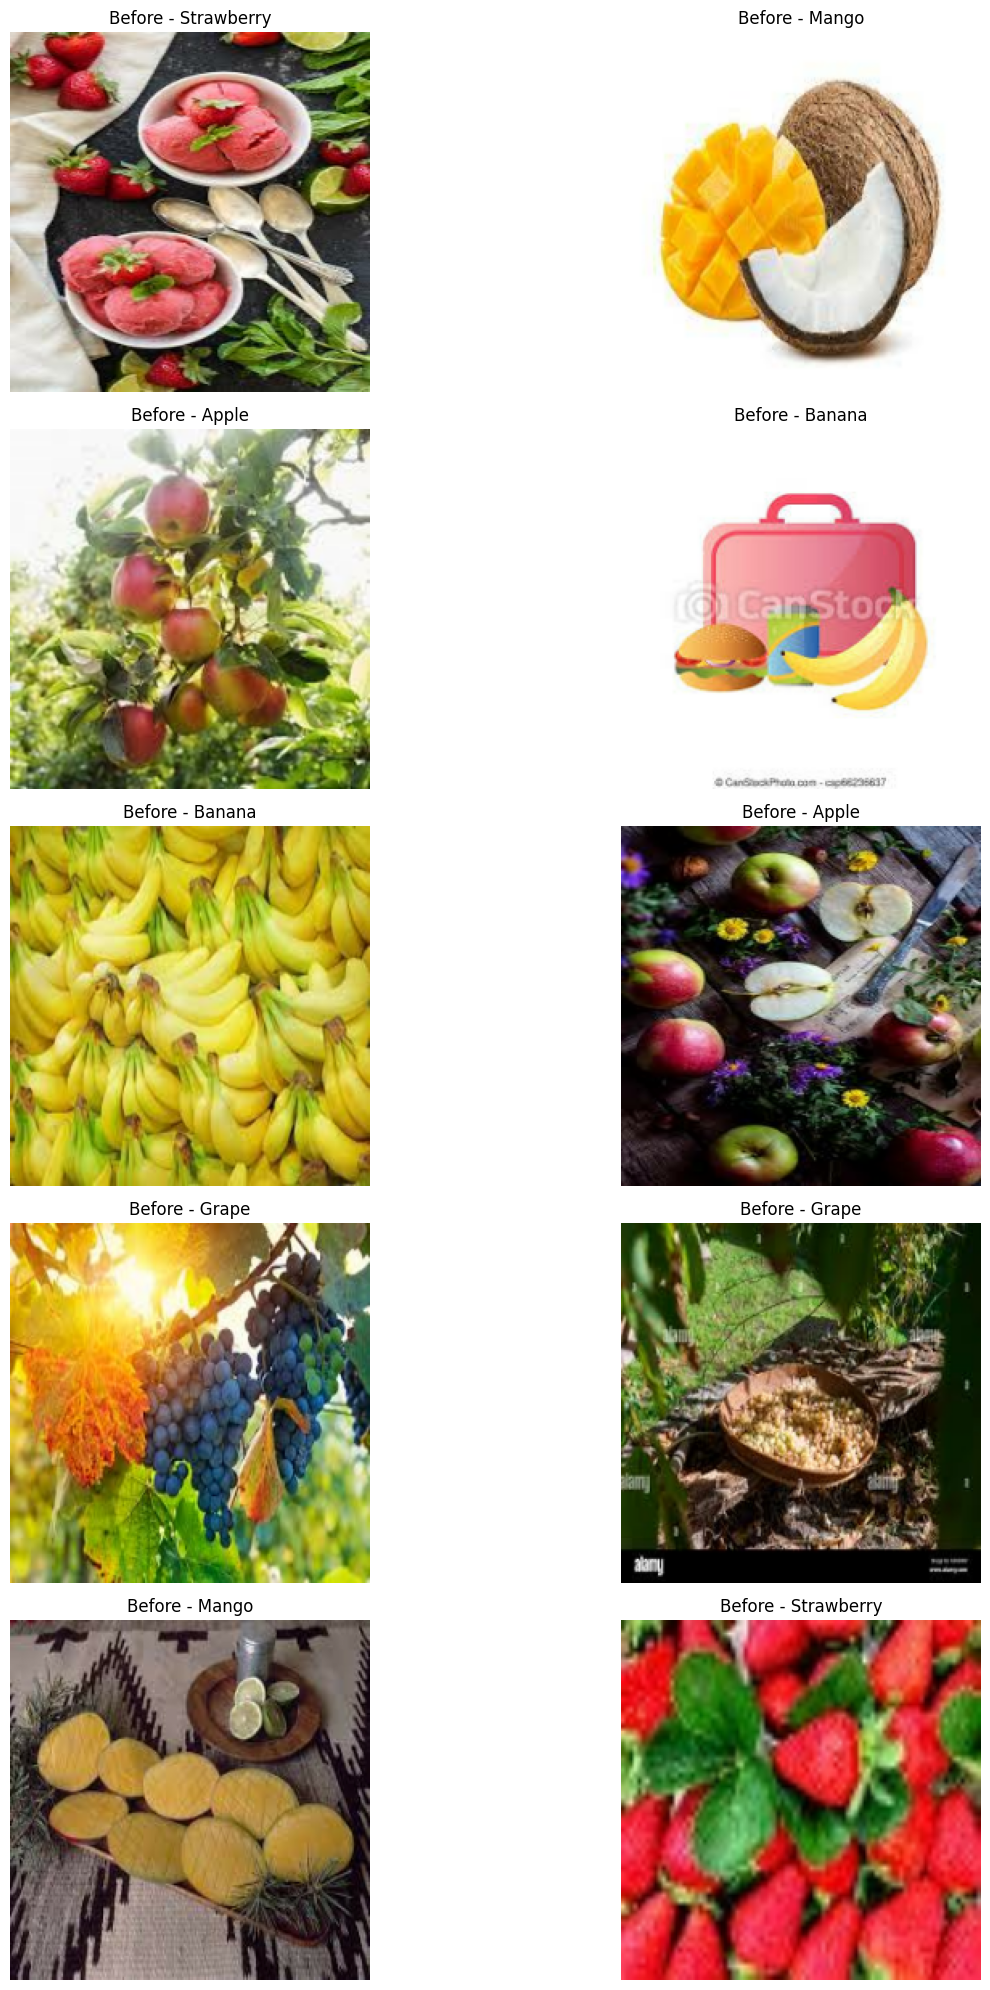

In [ ]:
plt.figure(figsize=(15, 20))

images_per_class = 2
shown_count = {class_name: 0 for class_name in Class_Names}
plot_index = 1

for images, labels in Train_Dataset:

    for i in range(len(images)):

        class_name = Class_Names[labels[i]]

        if shown_count[class_name] < images_per_class:

            plt.subplot(
                Num_Classes,
                images_per_class,
                plot_index
            )

            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"Before - {class_name}")
            plt.axis("off")

            shown_count[class_name] += 1
            plot_index += 1

    if all(count == images_per_class for count in shown_count.values()):
        break

plt.tight_layout()
plt.show()

In [ ]:
Data_Augmentation_Part2 = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="aug_part2")

In [ ]:
Data_Augmentation_Scratch = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="aug_scratch")

## Augmented Image Visualization

To better understand the effect of the data augmentation layers, let's visualize some samples from the training dataset after applying these augmentations. This helps confirm that the transformations are being applied as expected and to observe the variety introduced into the training data.

In [ ]:
Train_Dataset = Train_Dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)
Validation_Dataset = Validation_Dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)
Test_Dataset = Test_Dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

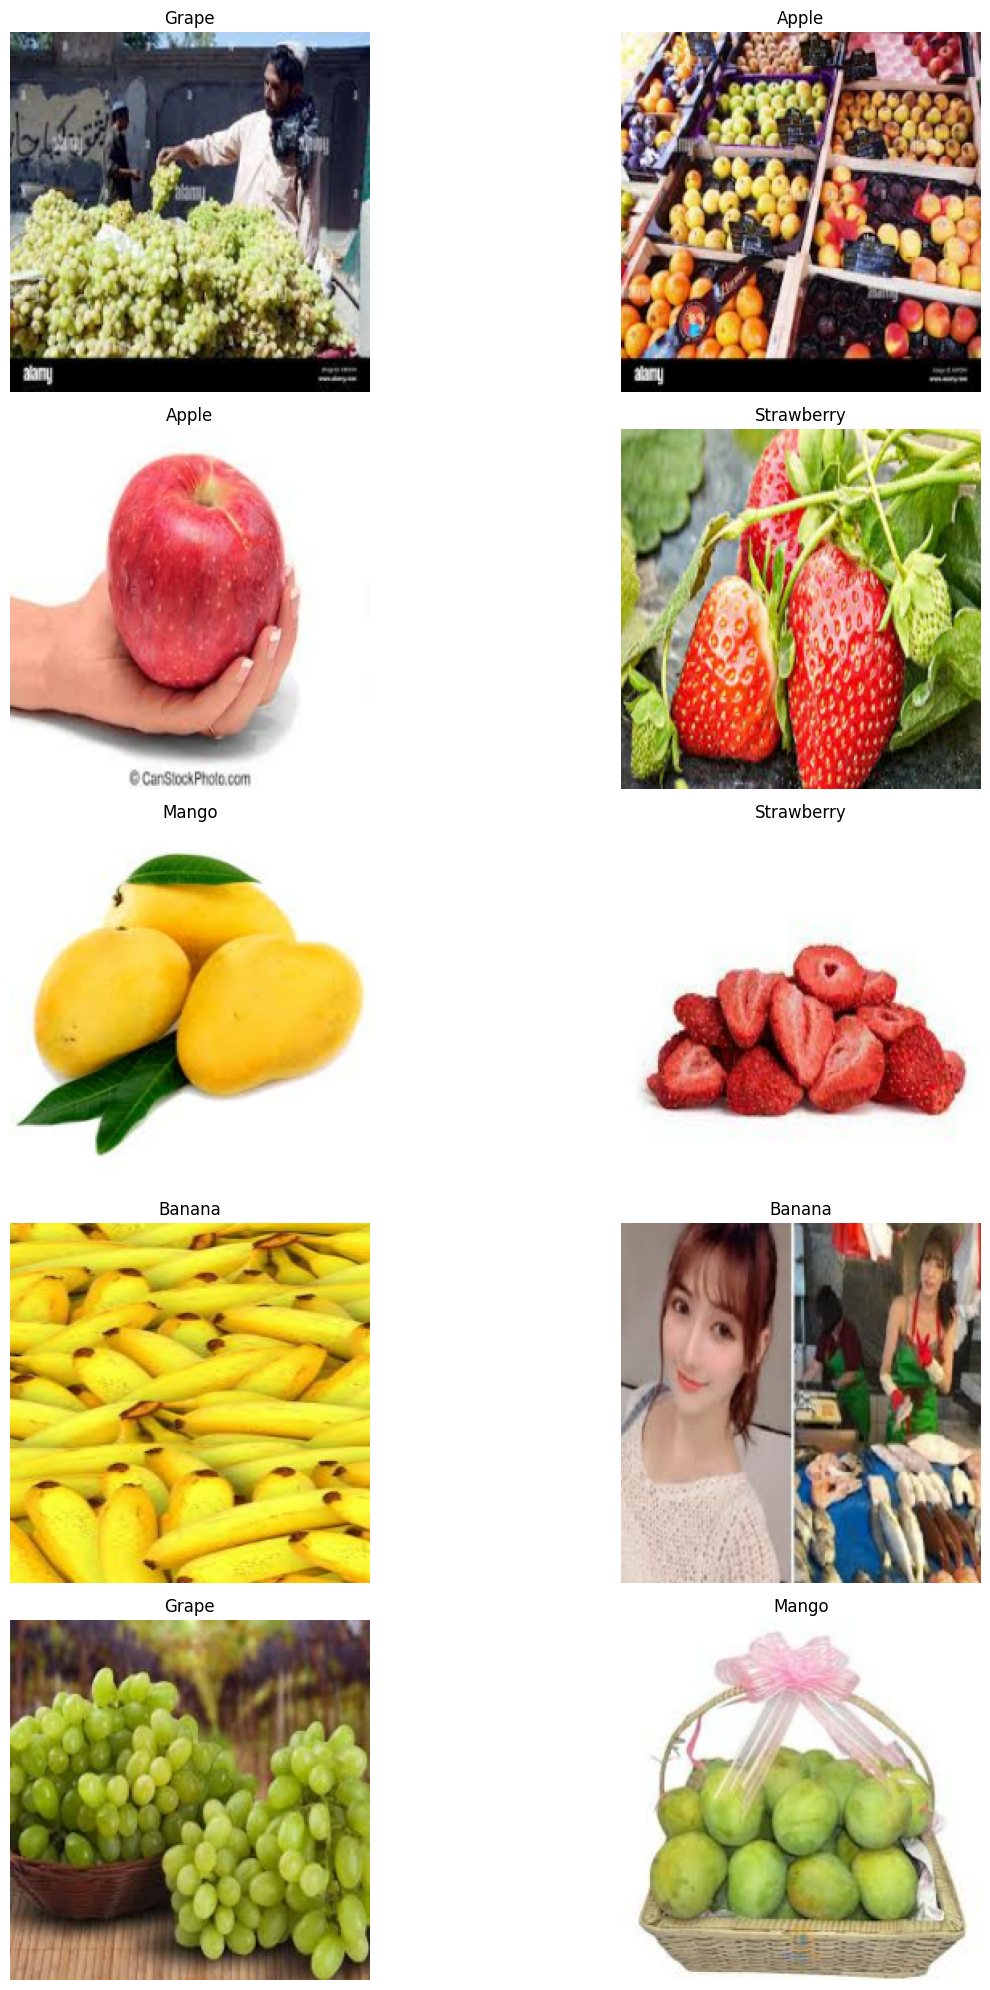

In [ ]:
plt.figure(figsize=(15, 20))

images_per_class = 2
shown_count = {class_name: 0 for class_name in Class_Names}

plot_index = 1

for images, labels in Train_Dataset:

    for i in range(len(images)):

        class_name = Class_Names[labels[i]]

        if shown_count[class_name] < images_per_class:

            ax = plt.subplot(
                Num_Classes,
                images_per_class,
                plot_index
            )

            plt.imshow(images[i].numpy())
            plt.title(class_name)
            plt.axis("off")

            shown_count[class_name] += 1
            plot_index += 1

    # Stop when all classes have 2 images
    if all(count == images_per_class for count in shown_count.values()):
        break

plt.tight_layout()
plt.show()

In [ ]:
Train_Dataset = Train_Dataset.shuffle(1000, reshuffle_each_iteration=True).cache().prefetch(AUTOTUNE)
Validation_Dataset = Validation_Dataset.cache("/tmp/val_cache").prefetch(AUTOTUNE)
Test_Dataset = Test_Dataset.cache("/tmp/test_cache").prefetch(AUTOTUNE)

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
Part2Model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    Data_Augmentation_Part2,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(Num_Classes, activation="softmax")
])

In [ ]:
Part2Model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/best_Part2_fruit_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

In [ ]:
history, time_part2 = train_and_time(
    Part2Model,
    Train_Dataset,
    Validation_Dataset,
    epochs=40,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6141 - loss: 1.0739
Epoch 1: val_loss improved from None to 0.44661, saving model to /content/drive/MyDrive/WORk/AI2/archive/best_Part2_fruit_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/best_Part2_fruit_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 2078s 256ms/step - accuracy: 0.7189 - loss: 0.7898 - val_accuracy: 0.8450 - val_loss: 0.4466 - learning_rate: 5.0000e-04
Epoch 2/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7914 - loss: 0.5553
Epoch 2: val_loss improved from 0.44661 to 0.38364, saving model to /content/drive/MyDrive/WORk/AI2/archive/best_Part2_fruit_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/best_Part2_fruit_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.8028 - loss: 0.5403 - val_accuracy: 0.8550 - val_loss: 0.3836 - learning_rate: 5.0000e-04
Epoch 3/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/st

In [ ]:
import os
for name, path in [("Train", train_dir), ("Valid", valid_dir), ("Test", test_dir)]:
    total = sum(len(files) for _, _, files in os.walk(path))
    print(f"{name}: {total} images")
    for class_folder in os.listdir(path):
        class_path = os.path.join(path, class_folder)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(f"  {class_folder}: {count} images")

Train: 9709 images
  Apple: 1940 images
  Grape: 1940 images
  Banana: 1940 images
  Mango: 1949 images
  Strawberry: 1940 images
Valid: 200 images
  Strawberry: 40 images
  Mango: 40 images
  Grape: 40 images
  Banana: 40 images
  Apple: 40 images
Test: 100 images
  Mango: 20 images
  Strawberry: 20 images
  Grape: 20 images
  Banana: 20 images
  Apple: 20 images


In [ ]:
print(test_dir)
print(valid_dir)

/content/drive/MyDrive/WORk/AI2/archive/FruitsClassification/test
/content/drive/MyDrive/WORk/AI2/archive/FruitsClassification/valid


In [ ]:
Part2Model = keras.models.load_model(
    "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/best_Part2_fruit_model.keras"
)
Test_Dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)
Test_Dataset = Test_Dataset.map(lambda x, y: (normalization_layer(x), y))
Test_Dataset = Test_Dataset.prefetch(buffer_size=AUTOTUNE)

#evaluate
test_loss, test_accuracy = Part2Model.evaluate(Test_Dataset)
print("Test Accuracy:", test_accuracy)

Found 100 files belonging to 5 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 28s 6s/step - accuracy: 0.9100 - loss: 0.2539
Test Accuracy: 0.9100000262260437


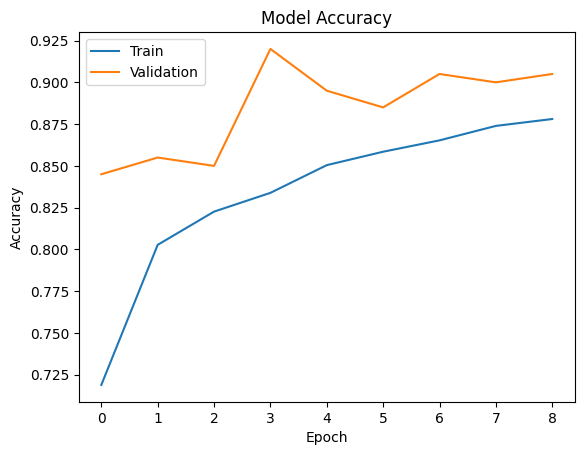

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


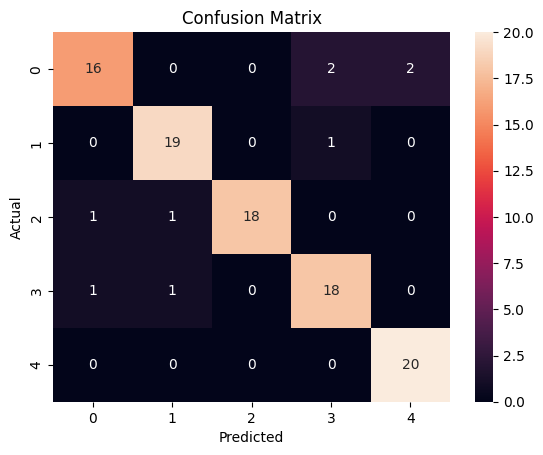

In [ ]:
y_true = []
y_pred = []

for images, labels in Test_Dataset:
    predictions = Part2Model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

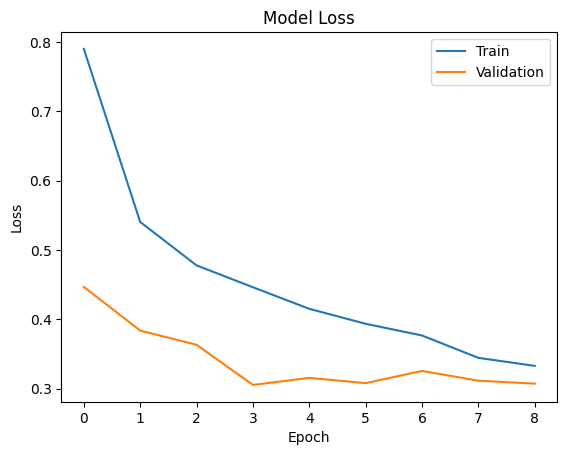

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
print("Train classes:", Class_Names)
print("Unique predictions:", set(y_pred))
print("Unique true labels:", set(y_true))

Train classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Unique predictions: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Unique true labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(Num_Classes)),  # ← fixes the ValueError
    target_names=Class_Names
))

              precision    recall  f1-score   support

       Apple       0.89      0.80      0.84        20
      Banana       0.90      0.95      0.93        20
       Grape       1.00      0.90      0.95        20
       Mango       0.86      0.90      0.88        20
  Strawberry       0.91      1.00      0.95        20

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



## Scratch Model

## New Baseline CNN Model

This section introduces a simple baseline Convolutional Neural Network (CNN) model to establish a performance benchmark. It consists of three convolutional blocks followed by a global average pooling layer and three dense layers, culminating in a softmax output for classification. This model serves as a foundation for comparison with more complex architectures.

In [ ]:
from tensorflow.keras.optimizers import Adam

Baseline_CNN = keras.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),
    Data_Augmentation_Scratch, # Using the same augmentation as the scratch model

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(Num_Classes, activation='softmax')
])

Baseline_CNN.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Baseline CNN Model Summary

The `model.summary()` below provides a concise overview of the Baseline CNN's architecture, listing each layer, its output shape, and the number of trainable parameters. This is crucial for understanding the model's complexity and how features are transformed through the network.

In [ ]:
print("Baseline CNN Model Summary:")
Baseline_CNN.summary()
print("\nThis summary shows the layer structure and parameter count for the Baseline CNN model.")

Baseline CNN Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,749 (655.27 KB)

 Trainable params: 167,749 (655.27 KB)

 Non-trainable params: 0 (0.00 B)


This summary shows the layer structure and parameter count for the Baseline CNN model.


### Training the Baseline CNN Model

Now, we will train the Baseline CNN model using the specified callbacks and measure its training time. The `train_and_time` helper function will be used to encapsulate the training process and report the elapsed time.

In [ ]:
baseline_callbacks = make_callbacks('/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/baseline_model.keras')
history_baseline, time_baseline = train_and_time(
    Baseline_CNN,
    Train_Dataset,
    Validation_Dataset,
    epochs=40,
    callbacks=baseline_callbacks
)

Epoch 1/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3331 - loss: 1.4595
Epoch 1: val_loss improved from None to 1.19488, saving model to /content/drive/MyDrive/WORk/AI2/archive/baseline_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/baseline_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.4165 - loss: 1.3229 - val_accuracy: 0.5050 - val_loss: 1.1949 - learning_rate: 5.0000e-04
Epoch 2/40
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5214 - loss: 1.1410
Epoch 2: val_loss improved from 1.19488 to 1.09244, saving model to /content/drive/MyDrive/WORk/AI2/archive/baseline_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/baseline_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.5387 - loss: 1.1172 - val_accuracy: 0.5300 - val_loss: 1.0924 - learning_rate: 5.0000e-04
Epoch 3/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5547 - loss: 1.079

### Evaluating the Baseline CNN Model

After training, the Baseline CNN model will be evaluated on the test dataset to assess its performance. This includes calculating test accuracy, generating a confusion matrix, and providing a classification report. The `plot_history` function will visualize the accuracy and loss curves during training.

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.7600 - loss: 0.6328
Baseline CNN Test Accuracy: 0.7600


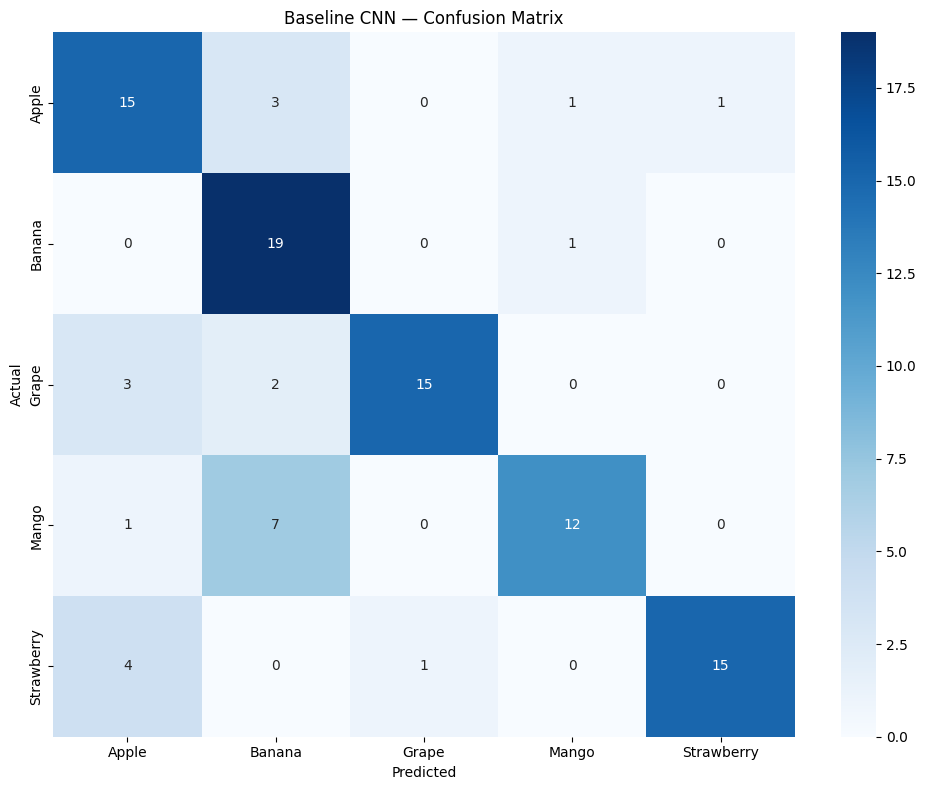


Baseline CNN — Classification Report
              precision    recall  f1-score   support

       Apple       0.65      0.75      0.70        20
      Banana       0.61      0.95      0.75        20
       Grape       0.94      0.75      0.83        20
       Mango       0.86      0.60      0.71        20
  Strawberry       0.94      0.75      0.83        20

    accuracy                           0.76       100
   macro avg       0.80      0.76      0.76       100
weighted avg       0.80      0.76      0.76       100



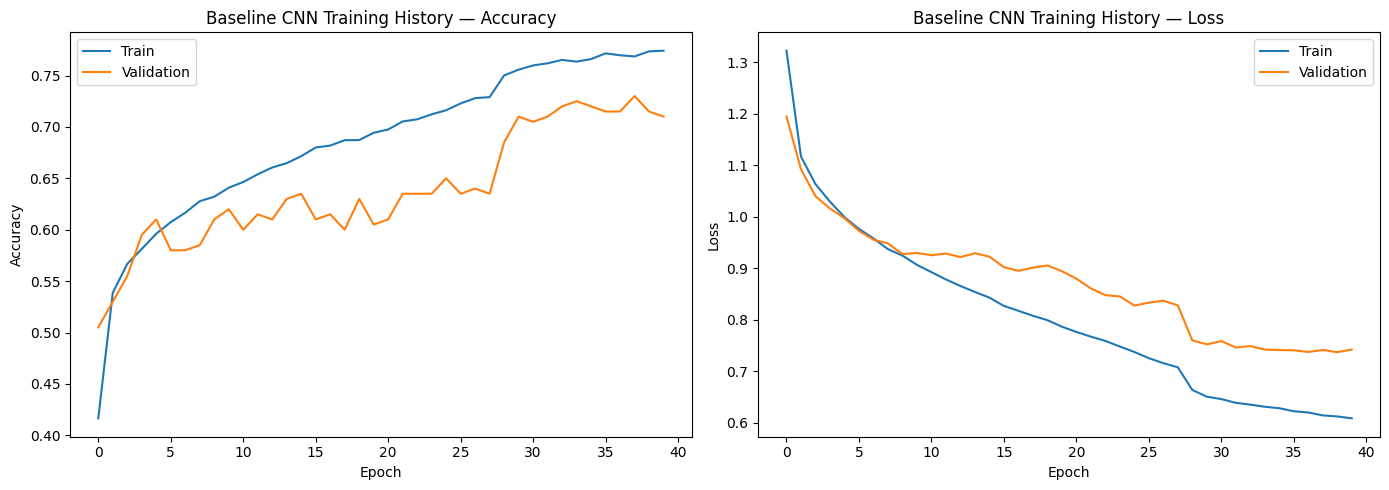

In [ ]:
Baseline_CNN = keras.models.load_model(
    '/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/baseline_model.keras'
)

test_loss_baseline, test_accuracy_baseline = Baseline_CNN.evaluate(Test_Dataset)
print(f"Baseline CNN Test Accuracy: {test_accuracy_baseline:.4f}")

y_true_baseline, y_pred_baseline = evaluate_model(Baseline_CNN, Test_Dataset, Class_Names, title="Baseline CNN")

plot_history(history_baseline, title="Baseline CNN Training History")

In [ ]:
Model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    Data_Augmentation_Scratch,

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(Num_Classes, activation="softmax")
])


### Deeper Scratch Model Summary

The `model.summary()` for the deeper scratch model provides insights into its more complex architecture, including a larger number of layers, batch normalization, and dropout layers. This detailed view helps in understanding the increase in trainable parameters and the flow of data through the network compared to the baseline model.

In [ ]:
print("Deeper Scratch Model Summary:")
Model.summary()
print("\nThis summary details the layer structure and parameter count for the Deeper Scratch model.")

Deeper Scratch Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)


This summary details the layer structure and parameter count for the Deeper Scratch model.


In [ ]:
Model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
scratch_callbacks = make_callbacks("/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/scratch_model.keras")
history_scratch, time_scratch = train_and_time(
    Model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=scratch_callbacks
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.4139 - loss: 1.6614
Epoch 1: val_loss improved from None to 1.81671, saving model to /content/drive/MyDrive/WORk/AI2/archive/scratch_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 76s 222ms/step - accuracy: 0.4664 - loss: 1.4517 - val_accuracy: 0.2700 - val_loss: 1.8167 - learning_rate: 5.0000e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5220 - loss: 1.2421
Epoch 2: val_loss improved from 1.81671 to 1.29964, saving model to /content/drive/MyDrive/WORk/AI2/archive/scratch_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 64s 209ms/step - accuracy: 0.5494 - loss: 1.1805 - val_accuracy: 0.4600 - val_loss: 1.2996 - learning_rate: 5.0000e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5567 - loss: 1.12

In [ ]:
Model = keras.models.load_model(
    "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/scratch_model.keras"
)


In [ ]:
test_loss, test_accuracy = Model.evaluate(Test_Dataset)

print("Scratch Model Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.8000 - loss: 0.4449
Scratch Model Test Accuracy: 0.800000011920929


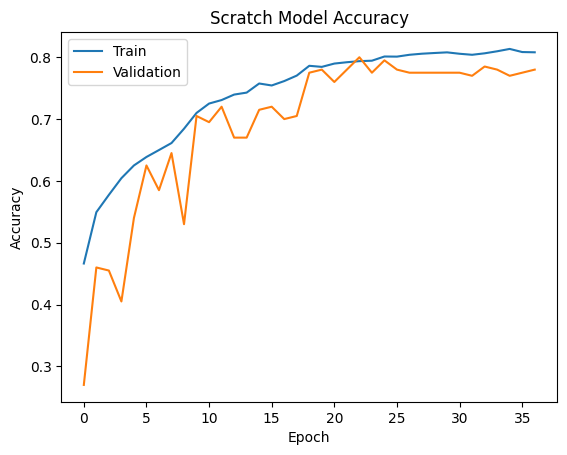

In [ ]:
plt.plot(history_scratch.history['accuracy'])
plt.plot(history_scratch.history['val_accuracy'])

plt.title("Scratch Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
y_true_scratch = []
y_pred_scratch = []

for images, labels in Test_Dataset:

    predictions = Model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true_scratch.extend(labels.numpy())
    y_pred_scratch.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step


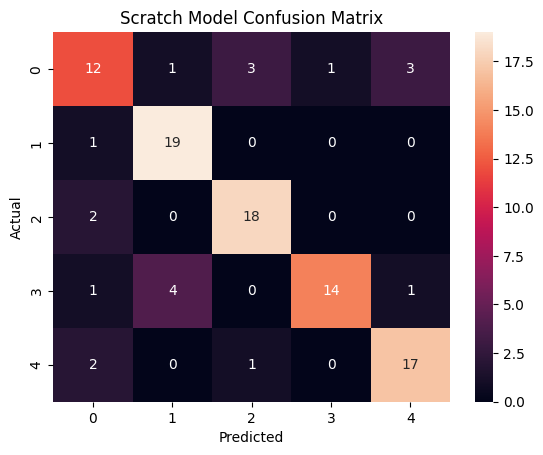

In [ ]:
cm_scratch = confusion_matrix(
    y_true_scratch,
    y_pred_scratch
)

sns.heatmap(cm_scratch, annot=True, fmt="d")

plt.title("Scratch Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

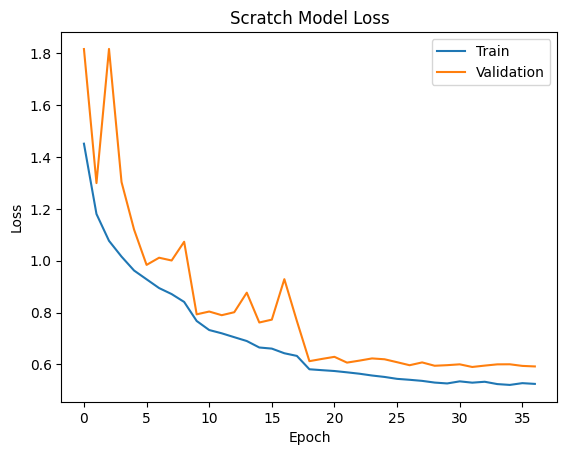

In [ ]:
plt.plot(history_scratch.history['loss'])
plt.plot(history_scratch.history['val_loss'])

plt.title("Scratch Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
print("Scratch Model Classes:", Class_Names)

print("Unique predictions:", set(y_pred_scratch))

print("Unique true labels:", set(y_true_scratch))

print(classification_report(
    y_true_scratch,
    y_pred_scratch,
    labels=list(range(Num_Classes)),
    target_names=Class_Names
))

Scratch Model Classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Unique predictions: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Unique true labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}
              precision    recall  f1-score   support

       Apple       0.67      0.60      0.63        20
      Banana       0.79      0.95      0.86        20
       Grape       0.82      0.90      0.86        20
       Mango       0.93      0.70      0.80        20
  Strawberry       0.81      0.85      0.83        20

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



## 1. SGD vs Adam Comparison

This section compares the performance of the Deeper Scratch Model when trained with two different optimizers: SGD (Stochastic Gradient Descent) and Adam. We will train the same model architecture twice, once with each optimizer, and then analyze their training histories and final test accuracies.

### Training with SGD Optimizer

We will now train the deeper scratch model using the SGD optimizer with a learning rate of 0.001 and momentum of 0.9. This will allow us to observe how SGD performs compared to Adam on this specific task.

In [ ]:
def build_deeper_scratch_model(augmentation_layer, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),
        augmentation_layer,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])
    return model

sgd_model = build_deeper_scratch_model(Data_Augmentation_Scratch, Num_Classes)

sgd_model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("SGD Model Summary:")
sgd_model.summary()

SGD Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
sgd_callbacks = make_callbacks("/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/sgd_deeper_scratch_model.keras")
history_sgd, time_sgd = train_and_time(
    sgd_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=sgd_callbacks
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.3869 - loss: 1.7258
Epoch 1: val_loss improved from None to 1.74903, saving model to /content/drive/MyDrive/WORk/AI2/archive/sgd_deeper_scratch_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/sgd_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 68s 215ms/step - accuracy: 0.4462 - loss: 1.4988 - val_accuracy: 0.2300 - val_loss: 1.7490 - learning_rate: 0.0010
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.5097 - loss: 1.2546
Epoch 2: val_loss improved from 1.74903 to 1.29760, saving model to /content/drive/MyDrive/WORk/AI2/archive/sgd_deeper_scratch_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/sgd_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 63s 207ms/step - accuracy: 0.5349 - loss: 1.1932 - val_accuracy: 0.4450 - val_loss: 1.2976 - learning_rate: 0.0010
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6700 - loss: 0.7239 
SGD Model Test Accuracy: 0.6700000166893005


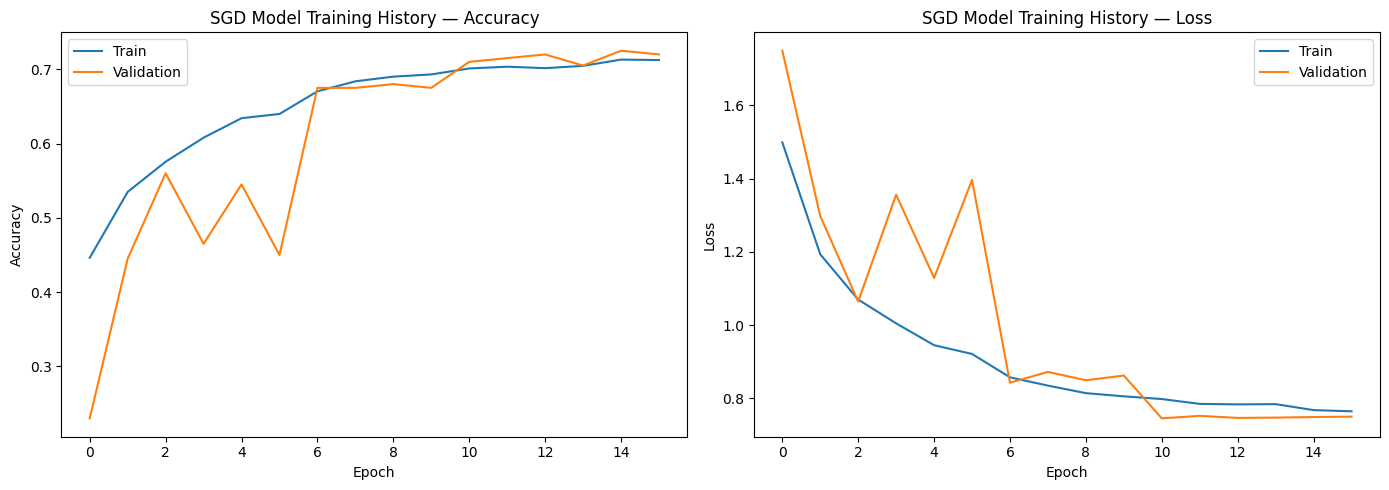

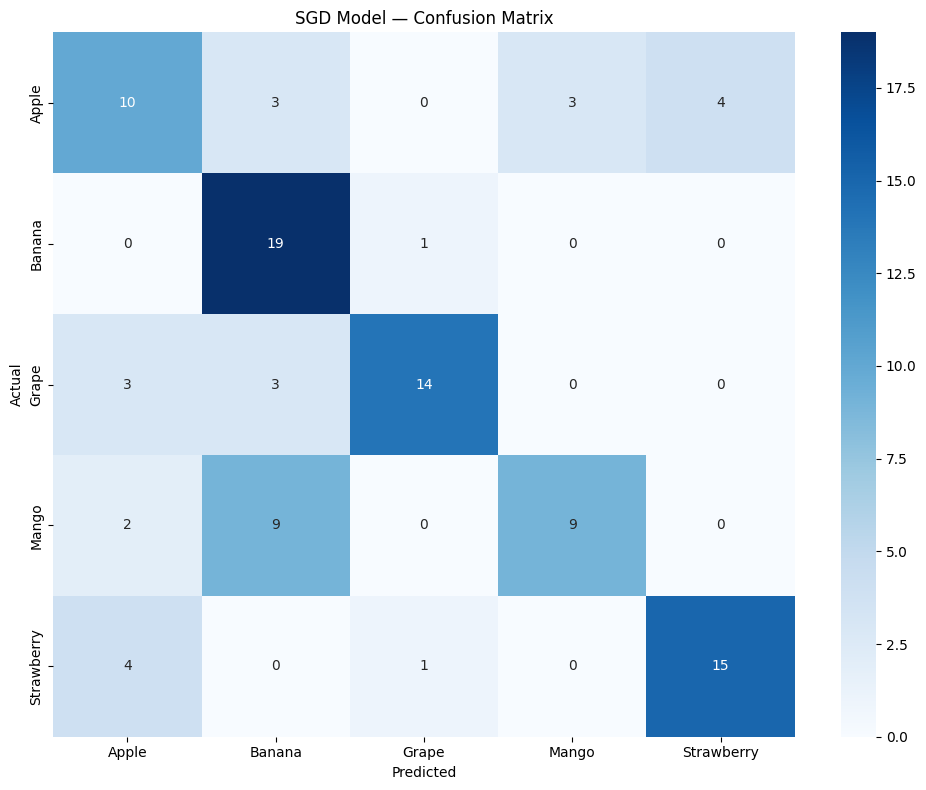


SGD Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.53      0.50      0.51        20
      Banana       0.56      0.95      0.70        20
       Grape       0.88      0.70      0.78        20
       Mango       0.75      0.45      0.56        20
  Strawberry       0.79      0.75      0.77        20

    accuracy                           0.67       100
   macro avg       0.70      0.67      0.67       100
weighted avg       0.70      0.67      0.67       100



In [ ]:
sgd_model = keras.models.load_model(
    "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/sgd_deeper_scratch_model.keras"
)

test_loss_sgd, test_accuracy_sgd = sgd_model.evaluate(Test_Dataset)
print("SGD Model Test Accuracy:", test_accuracy_sgd)

plot_history(history_sgd, title="SGD Model Training History")
y_true_sgd, y_pred_sgd = evaluate_model(sgd_model, Test_Dataset, Class_Names, title="SGD Model")

### Training with Adam Optimizer

Next, we will train an identical deeper scratch model using the Adam optimizer with a learning rate of 0.0005. This training will run independently of the previous SGD training, allowing for a direct comparison of optimizer performance.

In [ ]:
adam_model = build_deeper_scratch_model(Data_Augmentation_Scratch, Num_Classes)

adam_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Adam Model Summary:")
adam_model.summary()

Adam Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
adam_callbacks = make_callbacks("/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/adam_deeper_scratch_model.keras")
history_adam, time_adam = train_and_time(
    adam_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=adam_callbacks
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4081 - loss: 1.6738
Epoch 1: val_loss improved from None to 1.59280, saving model to /content/drive/MyDrive/WORk/AI2/archive/adam_deeper_scratch_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/adam_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 72s 217ms/step - accuracy: 0.4640 - loss: 1.4678 - val_accuracy: 0.3150 - val_loss: 1.5928 - learning_rate: 5.0000e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5278 - loss: 1.2536
Epoch 2: val_loss improved from 1.59280 to 1.09265, saving model to /content/drive/MyDrive/WORk/AI2/archive/adam_deeper_scratch_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/adam_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 64s 209ms/step - accuracy: 0.5518 - loss: 1.1797 - val_accuracy: 0.5300 - val_loss: 1.0926 - learning_rate: 5.0000e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.8100 - loss: 0.4635 
Adam Model Test Accuracy: 0.8100000023841858


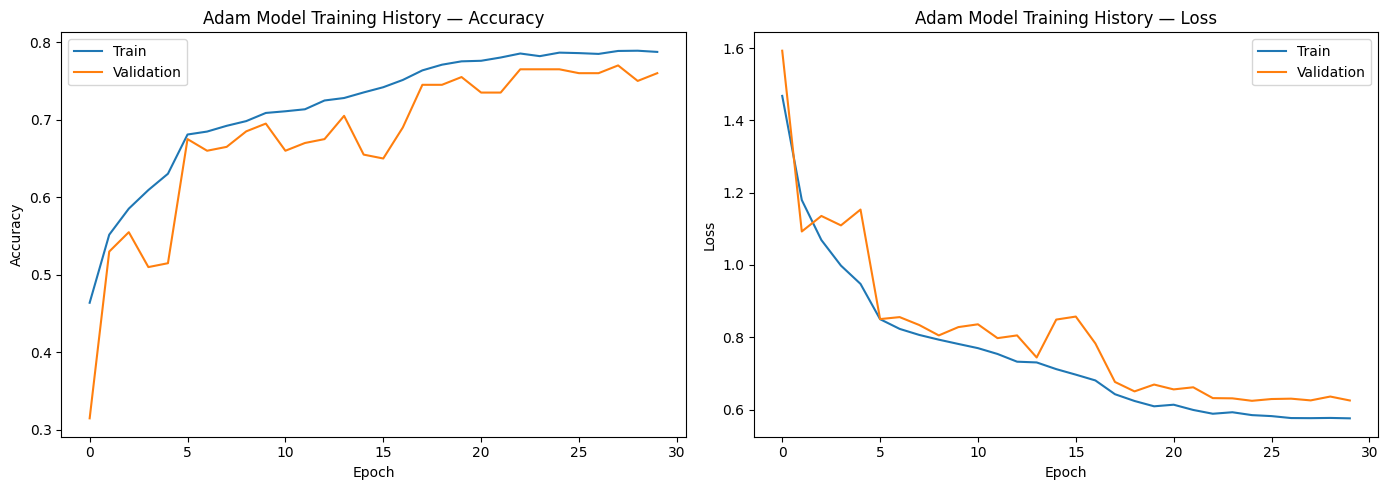

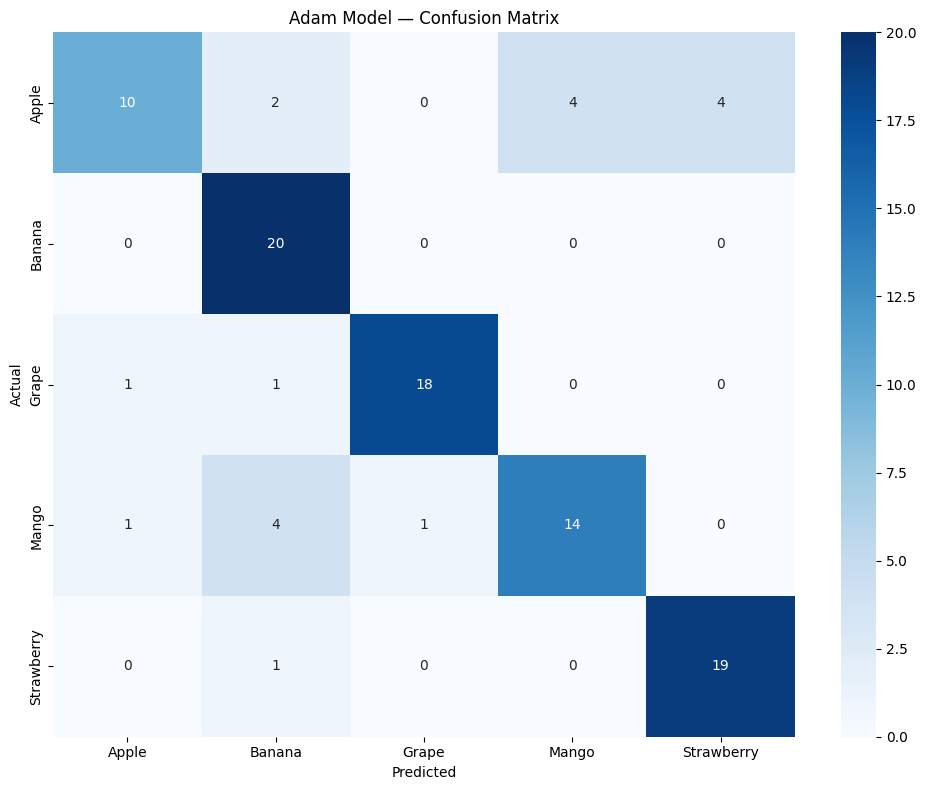


Adam Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.83      0.50      0.62        20
      Banana       0.71      1.00      0.83        20
       Grape       0.95      0.90      0.92        20
       Mango       0.78      0.70      0.74        20
  Strawberry       0.83      0.95      0.88        20

    accuracy                           0.81       100
   macro avg       0.82      0.81      0.80       100
weighted avg       0.82      0.81      0.80       100



In [ ]:
adam_model = keras.models.load_model(
    "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/adam_deeper_scratch_model.keras"
)

test_loss_adam, test_accuracy_adam = adam_model.evaluate(Test_Dataset)
print("Adam Model Test Accuracy:", test_accuracy_adam)

plot_history(history_adam, title="Adam Model Training History")
y_true_adam, y_pred_adam = evaluate_model(adam_model, Test_Dataset, Class_Names, title="Adam Model")

### SGD vs Adam Comparison Results

In this section, we compare the final test accuracies of the Deeper Scratch Model trained with SGD and Adam optimizers. This summary table provides a concise overview of their performance.

In [ ]:
print("\n--- Optimizer Comparison Summary ---")
print(f"SGD Model Test Accuracy: {test_accuracy_sgd:.4f}")
print(f"Adam Model Test Accuracy: {test_accuracy_adam:.4f}")


--- Optimizer Comparison Summary ---
SGD Model Test Accuracy: 0.6700
Adam Model Test Accuracy: 0.8100


#### Analysis of SGD vs Adam Performance

The performance comparison between the SGD (Stochastic Gradient Descent) and Adam optimizer showed that the Adam optimizer achieved better results in terms of classification accuracy. The SGD model obtained a test accuracy of 0.6700 (67%), whereas the Adam model achieved a test accuracy of 0.8100 (81%). This indicates that the Adam optimizer performed significantly better for the given dataset and learning task.

In terms of convergence, Adam appeared to train more efficiently and reached a better solution compared to SGD. Adam generally provides faster and more stable convergence because it adapts the learning rate automatically for each parameter during training. In contrast, SGD uses a fixed learning rate and may require careful tuning to achieve optimal performance. As a result, SGD can converge more slowly and may become stuck in suboptimal solutions if the learning rate is not ideal.

The smoother and more stable training process observed with Adam may have contributed to its improved accuracy and reduced optimization difficulties. Adam combines the benefits of momentum and adaptive learning rates, which makes it effective for handling complex datasets and deep learning models.

A possible reason for Adam’s superior performance is that the dataset and model architecture may have benefited from adaptive gradient updates, allowing the optimizer to learn meaningful patterns more efficiently. Additionally, the default hyperparameters of Adam are often well-suited for many deep learning tasks, while SGD may require further hyperparameter tuning, such as adjusting the learning rate or momentum, to achieve comparable results.

Overall, the Adam optimizer was found to be more effective than SGD for this task, as it produced higher accuracy and likely improved convergence stability during training.

## 2. Ablation Study

This ablation study investigates the impact of two key regularization techniques: Dropout and Batch Normalization, on the performance of the deeper scratch model. We will train two modified versions of the model:
1.  **No Dropout Model**: The deeper scratch model architecture but with all Dropout layers removed.
2.  **No Batch Normalization Model**: The deeper scratch model architecture but with all Batch Normalization layers removed.

Their performance will be evaluated against the full deeper scratch model to understand the contribution of each component.

### Training without Dropout

This model is identical to the deeper scratch model but excludes all Dropout layers. This experiment will help us understand the impact of Dropout on regularization and preventing overfitting for this dataset.

In [ ]:
def build_no_dropout_model(augmentation_layer, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),
        augmentation_layer,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        # Dropout layer removed

        layers.Dense(num_classes, activation="softmax")
    ])
    return model

no_dropout_model = build_no_dropout_model(Data_Augmentation_Scratch, Num_Classes)

no_dropout_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("No Dropout Model Summary:")
no_dropout_model.summary()

No Dropout Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
no_dropout_callbacks = make_callbacks("/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_dropout_model.keras")
history_no_dropout, time_no_dropout = train_and_time(
    no_dropout_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    initial_epoch=0,
    callbacks=no_dropout_callbacks
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.4778 - loss: 1.3133
Epoch 1: val_loss improved from None to 1.61067, saving model to /content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_dropout_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_dropout_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 2003s 435ms/step - accuracy: 0.5324 - loss: 1.1720 - val_accuracy: 0.3000 - val_loss: 1.6107 - learning_rate: 5.0000e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.6021 - loss: 1.0079
Epoch 2: val_loss did not improve from 1.61067
304/304 ━━━━━━━━━━━━━━━━━━━━ 64s 212ms/step - accuracy: 0.6061 - loss: 0.9918 - val_accuracy: 0.2450 - val_loss: 1.9467 - learning_rate: 5.0000e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.6364 - loss: 0.9261
Epoch 3: val_loss improved from 1.61067 to 1.39612, saving model to /content/drive/MyDrive/ai/WORk/WORk/AI2

4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 8s/step - accuracy: 0.8300 - loss: 0.4281
No Dropout Model Test Accuracy: 0.8299999833106995


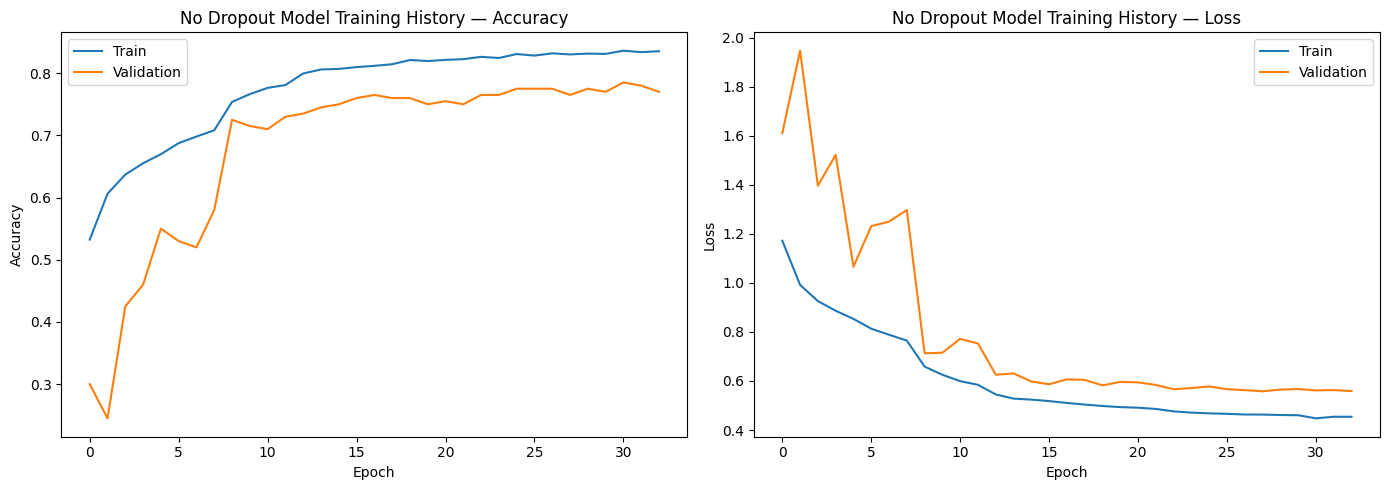

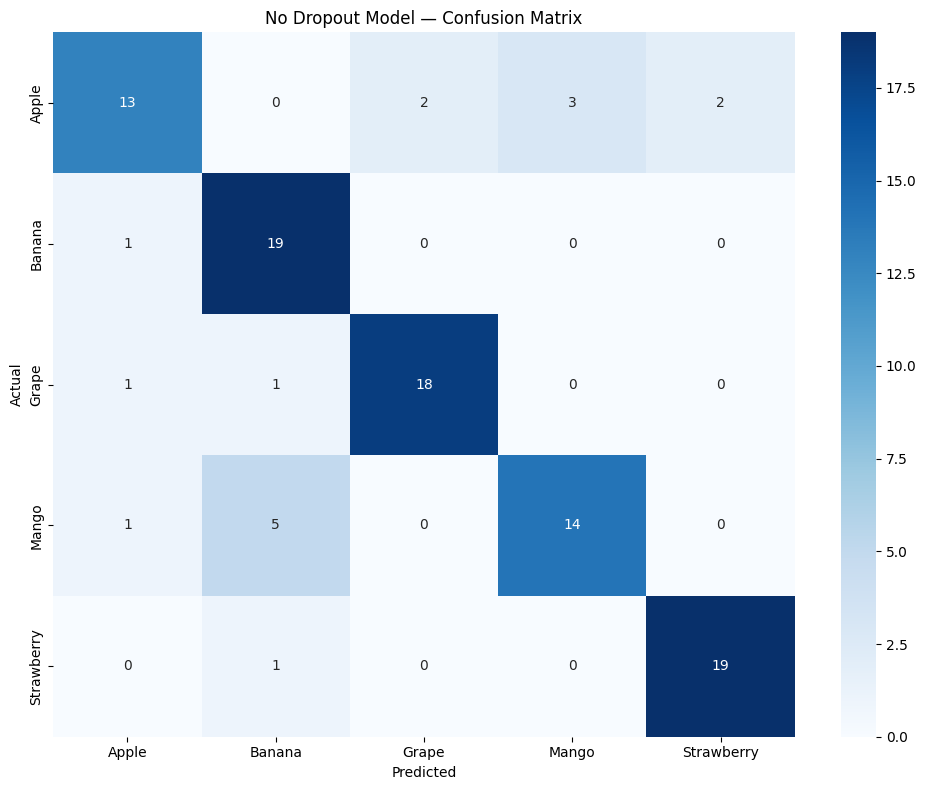


No Dropout Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.81      0.65      0.72        20
      Banana       0.73      0.95      0.83        20
       Grape       0.90      0.90      0.90        20
       Mango       0.82      0.70      0.76        20
  Strawberry       0.90      0.95      0.93        20

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100



In [ ]:
no_dropout_model = keras.models.load_model(
    "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_dropout_model.keras"
)

test_loss_no_dropout, test_accuracy_no_dropout = no_dropout_model.evaluate(Test_Dataset)
print("No Dropout Model Test Accuracy:", test_accuracy_no_dropout)

plot_history(history_no_dropout, title="No Dropout Model Training History")
y_true_no_dropout, y_pred_no_dropout = evaluate_model(no_dropout_model, Test_Dataset, Class_Names, title="No Dropout Model")

### Training without Batch Normalization

This model removes all Batch Normalization layers from the deeper scratch architecture. This experiment aims to demonstrate the role of Batch Normalization in stabilizing training and potentially improving model performance and convergence.

In [ ]:
def build_no_batchnorm_model(augmentation_layer, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),
        augmentation_layer,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])
    return model

no_batchnorm_model = build_no_batchnorm_model(Data_Augmentation_Scratch, Num_Classes)

no_batchnorm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("No Batch Normalization Model Summary:")
no_batchnorm_model.summary()

No Batch Normalization Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,253 (2.48 MB)

 Trainable params: 649,253 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
no_batchnorm_callbacks = make_callbacks("/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_batchnorm_model.keras")
history_no_batchnorm, time_no_batchnorm = train_and_time(
    no_batchnorm_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=no_batchnorm_callbacks
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.3740 - loss: 1.3887
Epoch 1: val_loss improved from None to 1.16899, saving model to /content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_batchnorm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_batchnorm_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 45s 138ms/step - accuracy: 0.4318 - loss: 1.2998 - val_accuracy: 0.5050 - val_loss: 1.1690 - learning_rate: 5.0000e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5184 - loss: 1.1460
Epoch 2: val_loss improved from 1.16899 to 1.11703, saving model to /content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_batchnorm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_batchnorm_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 40s 132ms/step - accuracy: 0.5180 - loss: 1.1531 - val_accuracy: 0.6

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8100 - loss: 0.5678
No Batch Normalization Model Test Accuracy: 0.8100000023841858


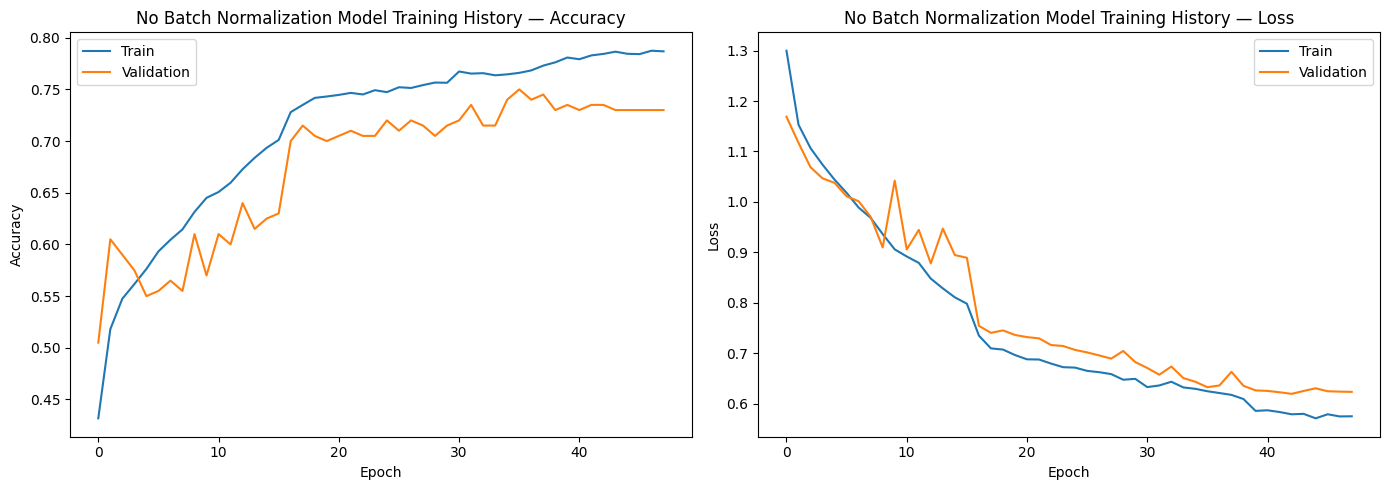

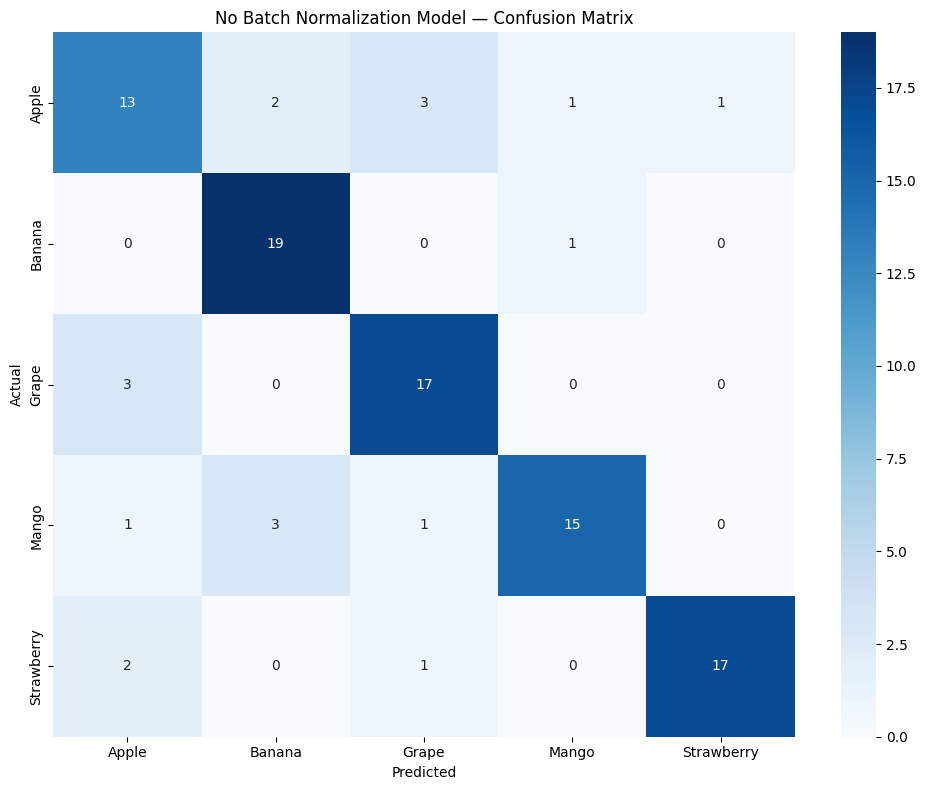


No Batch Normalization Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.68      0.65      0.67        20
      Banana       0.79      0.95      0.86        20
       Grape       0.77      0.85      0.81        20
       Mango       0.88      0.75      0.81        20
  Strawberry       0.94      0.85      0.89        20

    accuracy                           0.81       100
   macro avg       0.82      0.81      0.81       100
weighted avg       0.82      0.81      0.81       100



In [ ]:
no_batchnorm_model = keras.models.load_model(
    "/content/drive/MyDrive/ai/WORk/WORk/AI2/archive/FruitsClassification/no_batchnorm_model.keras"
)

test_loss_no_batchnorm, test_accuracy_no_batchnorm = no_batchnorm_model.evaluate(Test_Dataset)
print("No Batch Normalization Model Test Accuracy:", test_accuracy_no_batchnorm)

plot_history(history_no_batchnorm, title="No Batch Normalization Model Training History")
y_true_no_batchnorm, y_pred_no_batchnorm = evaluate_model(no_batchnorm_model, Test_Dataset, Class_Names, title="No Batch Normalization Model")

### Ablation Study Summary

This section summarizes the test accuracies of the full deeper scratch model, the model without Dropout, and the model without Batch Normalization. This comparison highlights the individual contribution of these components to the overall model performance.

In [ ]:
print("\n--- Ablation Study Summary ---")
print(f"No Dropout Model Test Accuracy: {test_accuracy_no_dropout:.4f}")
print(f"No Batch Normalization Model Test Accuracy: {test_accuracy_no_batchnorm:.4f}")


--- Ablation Study Summary ---
No Dropout Model Test Accuracy: 0.8300
No Batch Normalization Model Test Accuracy: 0.8100


In [ ]:
print(f"Full Deeper Scratch Model (Adam) Test Accuracy: {test_accuracy_adam:.4f}")

**Analysis of Ablation Study Results**

The ablation study highlights the importance of both Dropout and Batch Normalization in improving the model’s generalization and training performance.

Effect of Removing Dropout:
When Dropout was removed, the training accuracy slightly increased, but the validation/test accuracy decreased. This suggests that the model began to overfit the training data because Dropout normally helps prevent neurons from relying too heavily on each other. Without it, the network memorized training patterns more easily instead of learning features that generalize well to unseen data.

Effect of Removing Batch Normalization:
Removing Batch Normalization caused a noticeable drop in accuracy and made training less stable. The model converged more slowly and showed larger fluctuations in loss during training. Batch Normalization helps stabilize the distribution of activations across layers, allowing faster and more reliable learning. Without it, optimization becomes harder and the model is more sensitive to initialization and learning rate settings.

Overall Insights:
The results indicate that both Dropout and Batch Normalization play important roles in this task. Dropout mainly improves generalization by reducing overfitting, while Batch Normalization improves training stability and convergence speed. The best performance was achieved when both techniques were used together, showing that they complement each other in building a more robust and reliable neural network model.

## 3. Training Time Comparison Table

This table provides a concise overview of the total training time for each significant model trained during this notebook. Understanding training efficiency is crucial for practical applications and resource management.

In [ ]:
print("\n--- Training Time Comparison ---")
print("{:<30} {:>10}".format("Model", "Time (m:s)"))
print("-" * 45)

def format_time(seconds):
    mins, secs = divmod(int(seconds), 60)
    return f"{mins}m {secs}s"

# For Part2Model (Transfer Learning)
print("{:<30} {:>10}".format("Transfer Learning (Part2)", format_time(time_part2)))
# For Baseline CNN
print("{:<30} {:>10}".format("Baseline CNN", format_time(time_baseline)))
# For Deeper Scratch Model (Original Adam Training)
print("{:<30} {:>10}".format("Deeper Scratch (Adam)", format_time(time_scratch)))
# For Deeper Scratch Model (SGD)
print("{:<30} {:>10}".format("Deeper Scratch (SGD)", format_time(time_sgd)))
# For Deeper Scratch Model (Adam for comparison)
print("{:<30} {:>10}".format("Deeper Scratch (Adam Comp)", format_time(time_adam)))
# For Ablation: No Dropout
print("{:<30} {:>10}".format("Deeper Scratch (No Dropout)", format_time(time_no_dropout)))
# For Ablation: No Batch Normalization
print("{:<30} {:>10}".format("Deeper Scratch (No BatchNorm)", format_time(time_no_batchnorm)))


## 4. Sample Image Inference

This section demonstrates the inference capability of one of the best-performing models (e.g., the Adam-optimized deeper scratch model) by predicting the class of 9 randomly selected images from the test dataset. Each image will be displayed along with its predicted and true label, color-coded for correctness.

In [ ]:
import random

inference_model = adam_model

plt.figure(figsize=(10, 10))
# To get truly random images, we'll iterate through the dataset and collect some, then pick from them.
all_test_images = []
all_test_labels = []
for images, labels in Test_Dataset.unbatch(): # Unbatch to get individual image/label pairs
    all_test_images.append(images.numpy())
    all_test_labels.append(labels.numpy())

# Select 9 random indices
random_indices = random.sample(range(len(all_test_images)), 9)

for i, idx in enumerate(random_indices):
    image = all_test_images[idx]
    true_label_idx = all_test_labels[idx]

    # Make prediction (add batch dimension for single image inference)
    prediction = inference_model.predict(np.expand_dims(image, axis=0), verbose=0)
    predicted_label_idx = np.argmax(prediction)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)

    true_label_name = Class_Names[true_label_idx]
    predicted_label_name = Class_Names[predicted_label_idx]

    color = "green" if predicted_label_idx == true_label_idx else "red"
    title = f"True: {true_label_name}\nPred: {predicted_label_name}"
    plt.title(title, color=color)
    plt.axis("off")

plt.tight_layout()
plt.suptitle("Sample Image Inference (Adam Model)", y=1.02, fontsize=16)
plt.show()